In [2]:
!pip install -q ultralytics pytorch-lightning torchvision


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.6 MB/s eta 0:00:00a 0:00:01


In [3]:
from ultralytics import YOLO
import torch

print("Torch:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Torch: 2.8.0+cu126
CUDA Available: True


In [8]:
import shutil
import os

SRC = "/kaggle/input/pcb-defect-dataset/pcb-defect-dataset"
DST = "/kaggle/working/pcb-defect-dataset"

if not os.path.exists(DST):
    shutil.copytree(SRC, DST)

print("✅ Dataset copied to /kaggle/working")


✅ Dataset copied to /kaggle/working


In [9]:
!ls /kaggle/working/pcb-defect-dataset


data.yaml  test  train	val


In [10]:
DATA_YAML = "/kaggle/working/pcb-defect-dataset/data.yaml"


In [11]:
light_model.train(
    data=DATA_YAML,
    epochs=30,
    imgsz=640,
    batch=16,
    project="pcb_lightweight",
    name="yolo11_light",
    optimizer="AdamW"
)


Ultralytics 8.4.6 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/pcb-defect-dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.yaml, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11_light2, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, pat

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fcf28a3ee40>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

In [12]:
metrics_light = light_model.val(
    data=DATA_YAML,
    imgsz=640
)

metrics_light


Ultralytics 8.4.6 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO11n summary (fused): 101 layers, 2,583,322 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1978.6±86.9 MB/s, size: 130.4 KB)
val: Scanning /kaggle/working/pcb-defect-dataset/val/labels.cache... 802 images, 264 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1066/1066 447.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 67/67 8.4it/s 7.9s0.2ss
                   all       1066       1595      0.962      0.948      0.974      0.531
            mouse_bite        140        280      0.967      0.951      0.979      0.535
                  spur        130        262      0.964      0.905      0.951      0.502
          missing_hole        118        229      0.995      0.996      0.995      0.591
                 short        158        327      0.931      0.956       0.96      0.522
          

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fcf24b4eba0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

In [13]:
print("⚙️ LIGHTWEIGHT MODEL METRICS\n")

print(f"Precision  : {metrics_light.box.p.mean():.4f}")
print(f"Recall     : {metrics_light.box.r.mean():.4f}")
print(f"mAP@0.5    : {metrics_light.box.map50:.4f}")
print(f"mAP@0.5:0.95 : {metrics_light.box.map:.4f}")


⚙️ LIGHTWEIGHT MODEL METRICS

Precision  : 0.9619
Recall     : 0.9482
mAP@0.5    : 0.9736
mAP@0.5:0.95 : 0.5309


In [16]:
!find /kaggle/working/pcb_lightweight -name best.pt


/kaggle/working/pcb_lightweight/yolo11_light2/weights/best.pt


In [17]:
from ultralytics import YOLO

MODEL_PATH = "/kaggle/working/pcb_lightweight/yolo11_light2/weights/best.pt"
DATA_YAML = "/kaggle/working/pcb-defect-dataset/data.yaml"

light_model = YOLO(MODEL_PATH)
print("✅ Lightweight model loaded successfully")


✅ Lightweight model loaded successfully


In [18]:
import shutil
import os

FIXED_PATH = "/kaggle/working/lightweight_best.pt"
shutil.copy(MODEL_PATH, FIXED_PATH)

print("✅ Model copied to:", FIXED_PATH)


✅ Model copied to: /kaggle/working/lightweight_best.pt


In [19]:
import shutil
import os

FIXED_PATH = "/kaggle/working/lightweight_best.pt"
shutil.copy(MODEL_PATH, FIXED_PATH)

print("✅ Model copied to:", FIXED_PATH)


✅ Model copied to: /kaggle/working/lightweight_best.pt


In [20]:
from ultralytics import YOLO

MODEL_PATH = "/kaggle/working/lightweight_best.pt"  # or exact best.pt path
DATA_YAML = "/kaggle/working/pcb-defect-dataset/data.yaml"

model = YOLO(MODEL_PATH)
print("✅ Lightweight YOLOv11 model loaded")


✅ Lightweight YOLOv11 model loaded


In [21]:
metrics_test = model.val(
    data=DATA_YAML,
    split="test",      # 🔥 test data
    imgsz=640,
    save=True,
    plots=True
)


Ultralytics 8.4.6 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO11n summary (fused): 101 layers, 2,583,322 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1791.9±443.2 MB/s, size: 118.6 KB)
val: Scanning /kaggle/working/pcb-defect-dataset/test/labels... 829 images, 239 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1068/1068 1.6Kit/s 0.7s.1s
val: New cache created: /kaggle/working/pcb-defect-dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 67/67 8.3it/s 8.0s0.1ss
                   all       1068       1662      0.961      0.952      0.976      0.526
            mouse_bite        131        262      0.961      0.954      0.984      0.525
                  spur        138        279      0.969      0.888       0.96      0.499
          missing_hole        145        283      0.979      0.997      0.994      0.574
                 short   

In [22]:
import numpy as np

precision_test = metrics_test.box.p.mean()
recall_test = metrics_test.box.r.mean()
f1_test = 2 * (precision_test * recall_test) / (precision_test + recall_test)

print("\n📊 TEST DATA METRICS (LIGHTWEIGHT MODEL)\n")
print(f"Precision     : {precision_test:.4f}")
print(f"Recall        : {recall_test:.4f}")
print(f"F1-score      : {f1_test:.4f}")
print(f"mAP@0.5       : {metrics_test.box.map50:.4f}")
print(f"mAP@0.5:0.95  : {metrics_test.box.map:.4f}")



📊 TEST DATA METRICS (LIGHTWEIGHT MODEL)

Precision     : 0.9612
Recall        : 0.9521
F1-score      : 0.9566
mAP@0.5       : 0.9761
mAP@0.5:0.95  : 0.5262


In [23]:
import pandas as pd

test_df = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1-score", "mAP@0.5", "mAP@0.5:0.95"],
    "Value": [
        precision_test,
        recall_test,
        f1_test,
        metrics_test.box.map50,
        metrics_test.box.map
    ]
})

test_df.to_csv("/kaggle/working/lightweight_test_metrics.csv", index=False)
test_df


,Metric,Value
0,Precision,0.961211
1,Recall,0.952070
2,F1-score,0.956618
3,mAP@0.5,0.976137
4,mAP@0.5:0.95,0.526235


In [24]:
metrics_all = model.val(
    data=DATA_YAML,
    split="val",       # validation = global performance
    imgsz=640,
    save=True,
    plots=True
)


Ultralytics 8.4.6 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1625.9±309.4 MB/s, size: 119.5 KB)
val: Scanning /kaggle/working/pcb-defect-dataset/val/labels.cache... 802 images, 264 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1066/1066 447.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 67/67 8.4it/s 8.0s<0.1s
                   all       1066       1595      0.962      0.948      0.974      0.531
            mouse_bite        140        280      0.967      0.951      0.979      0.535
                  spur        130        262      0.964      0.905      0.951      0.502
          missing_hole        118        229      0.995      0.996      0.995      0.591
                 short        158        327      0.931      0.956       0.96      0.522
          open_circuit        135        259      0.992      0.945      0.984      0.515
   

In [25]:
precision_all = metrics_all.box.p.mean()
recall_all = metrics_all.box.r.mean()
f1_all = 2 * (precision_all * recall_all) / (precision_all + recall_all)

print("\n📊 OVERALL (VALIDATION) METRICS\n")
print(f"Precision     : {precision_all:.4f}")
print(f"Recall        : {recall_all:.4f}")
print(f"F1-score      : {f1_all:.4f}")
print(f"mAP@0.5       : {metrics_all.box.map50:.4f}")
print(f"mAP@0.5:0.95  : {metrics_all.box.map:.4f}")




📊 OVERALL (VALIDATION) METRICS

Precision     : 0.9619
Recall        : 0.9482
F1-score      : 0.9550
mAP@0.5       : 0.9736
mAP@0.5:0.95  : 0.5309


In [26]:
overall_df = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1-score", "mAP@0.5", "mAP@0.5:0.95"],
    "Value": [
        precision_all,
        recall_all,
        f1_all,
        metrics_all.box.map50,
        metrics_all.box.map
    ]
})

overall_df.to_csv("/kaggle/working/lightweight_overall_metrics.csv", index=False)
overall_df


,Metric,Value
0,Precision,0.961896
1,Recall,0.948234
2,F1-score,0.955016
3,mAP@0.5,0.973642
4,mAP@0.5:0.95,0.530852


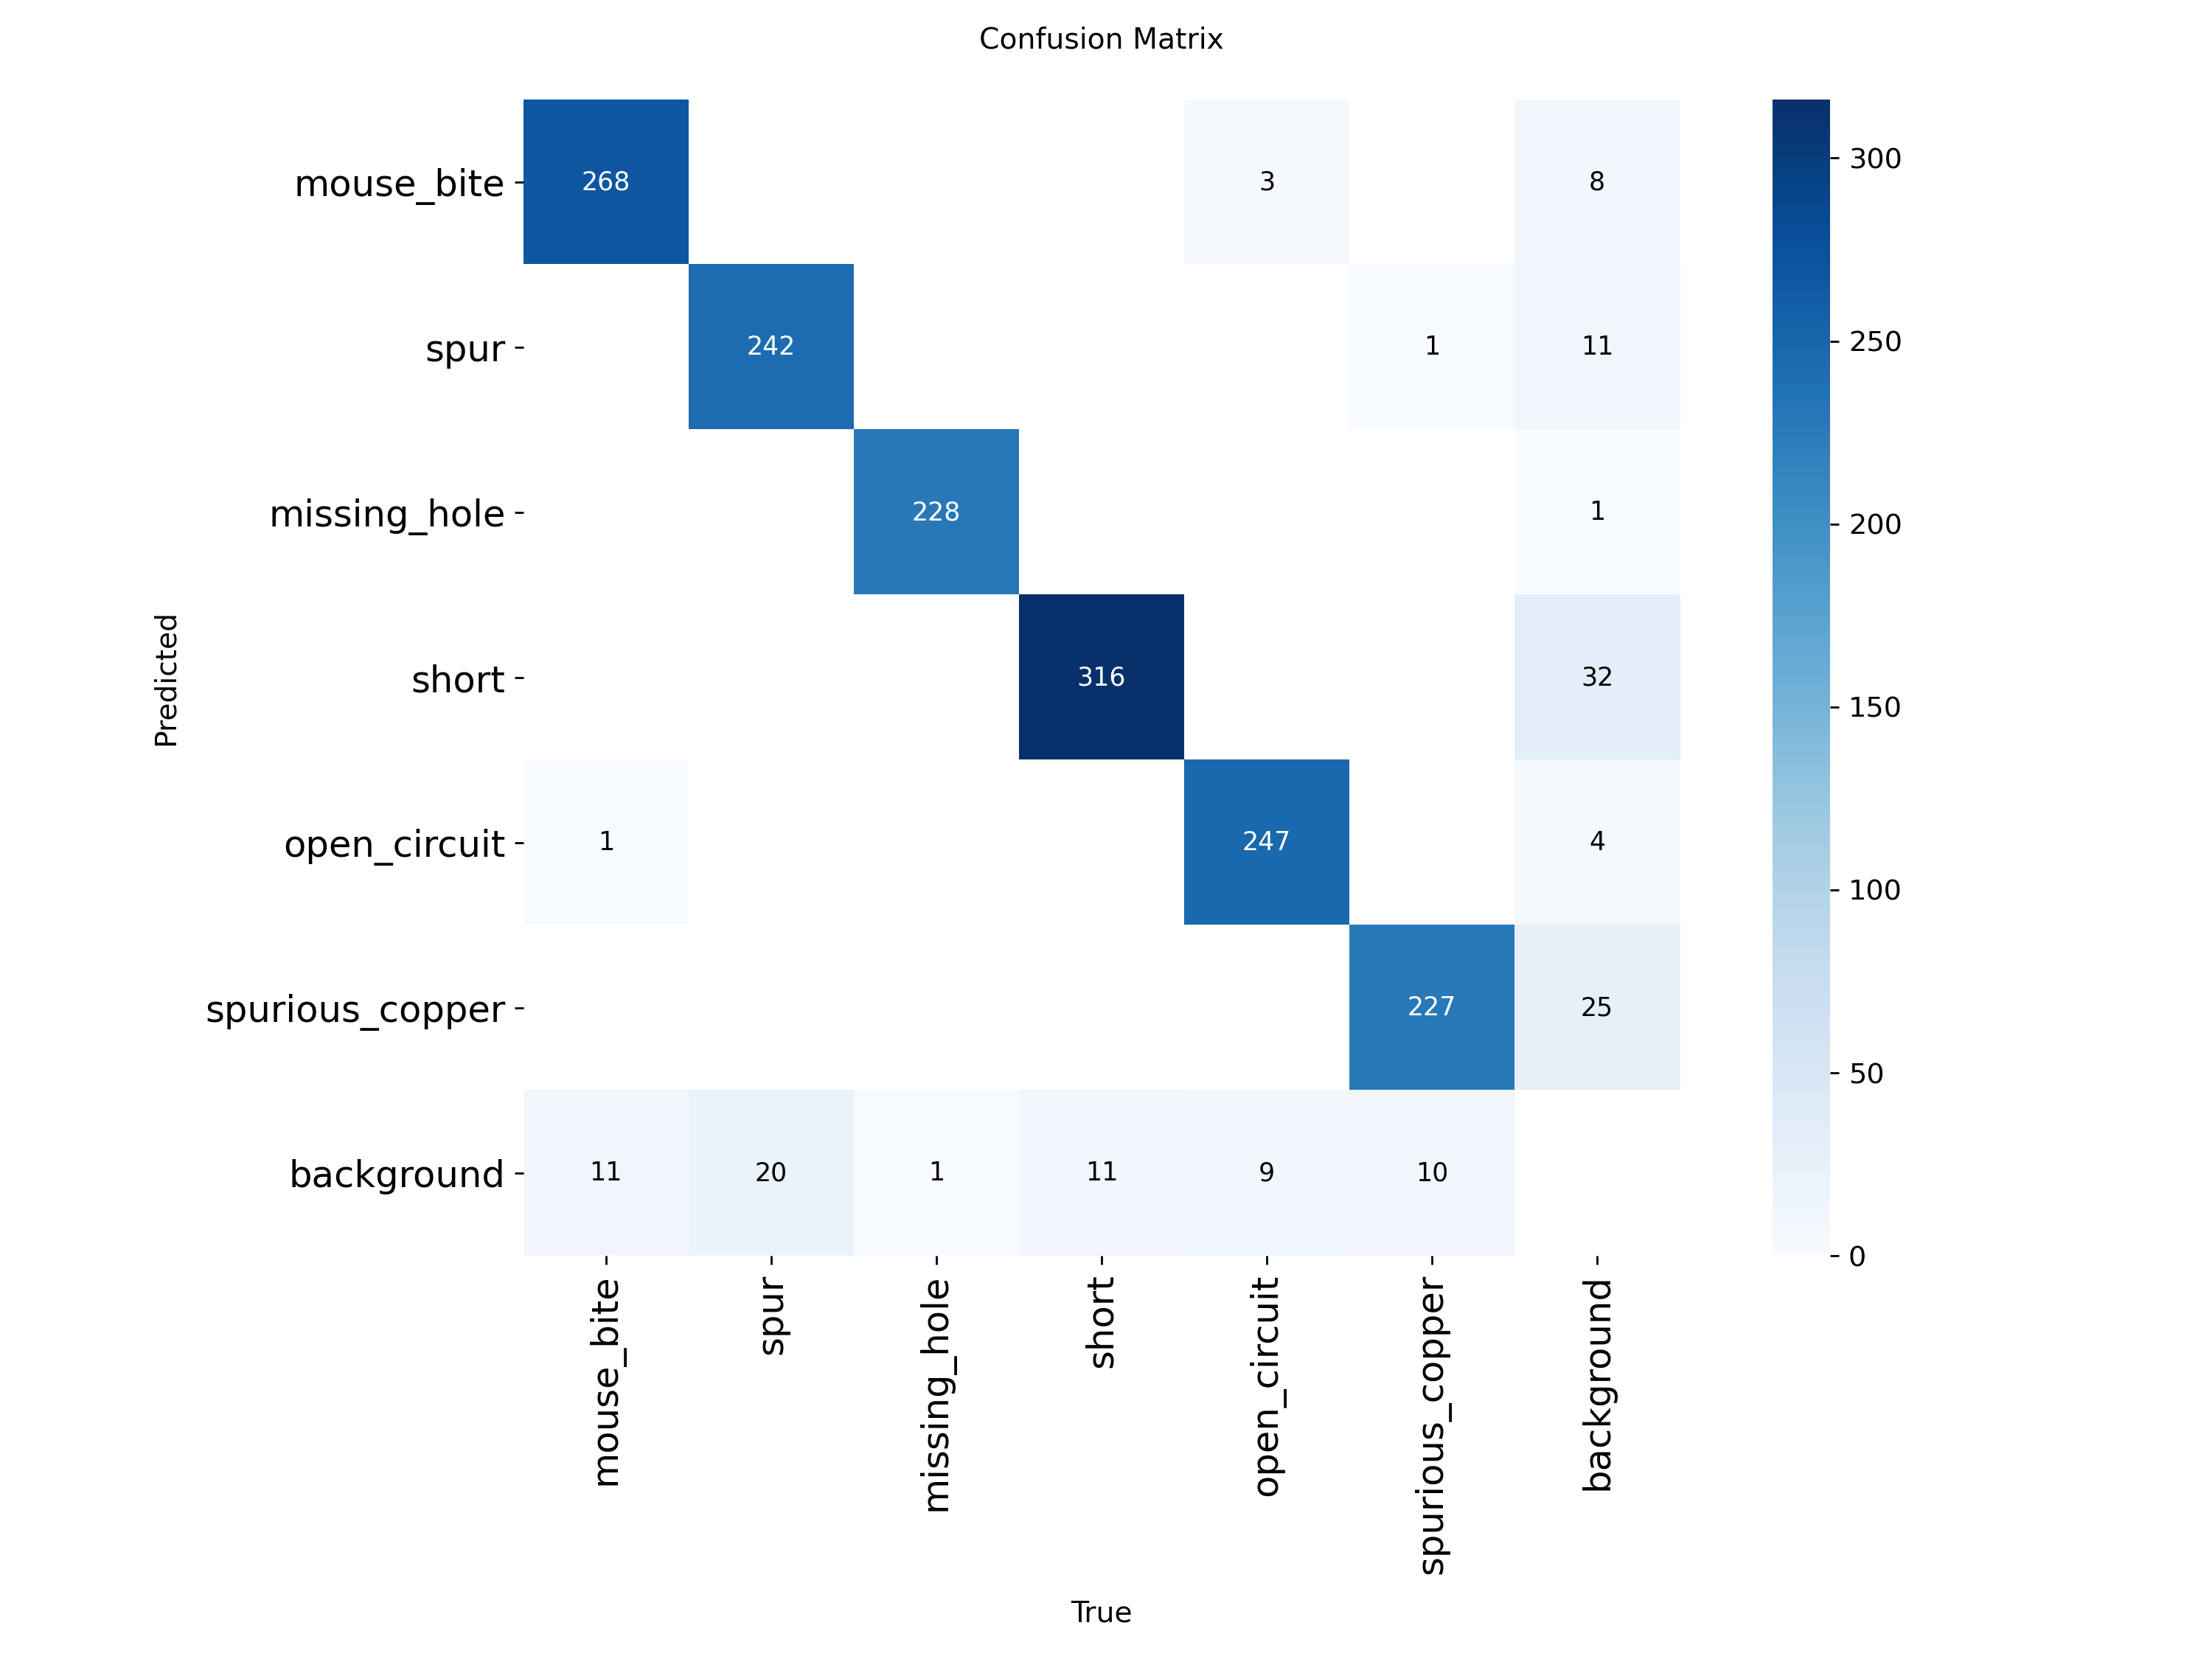

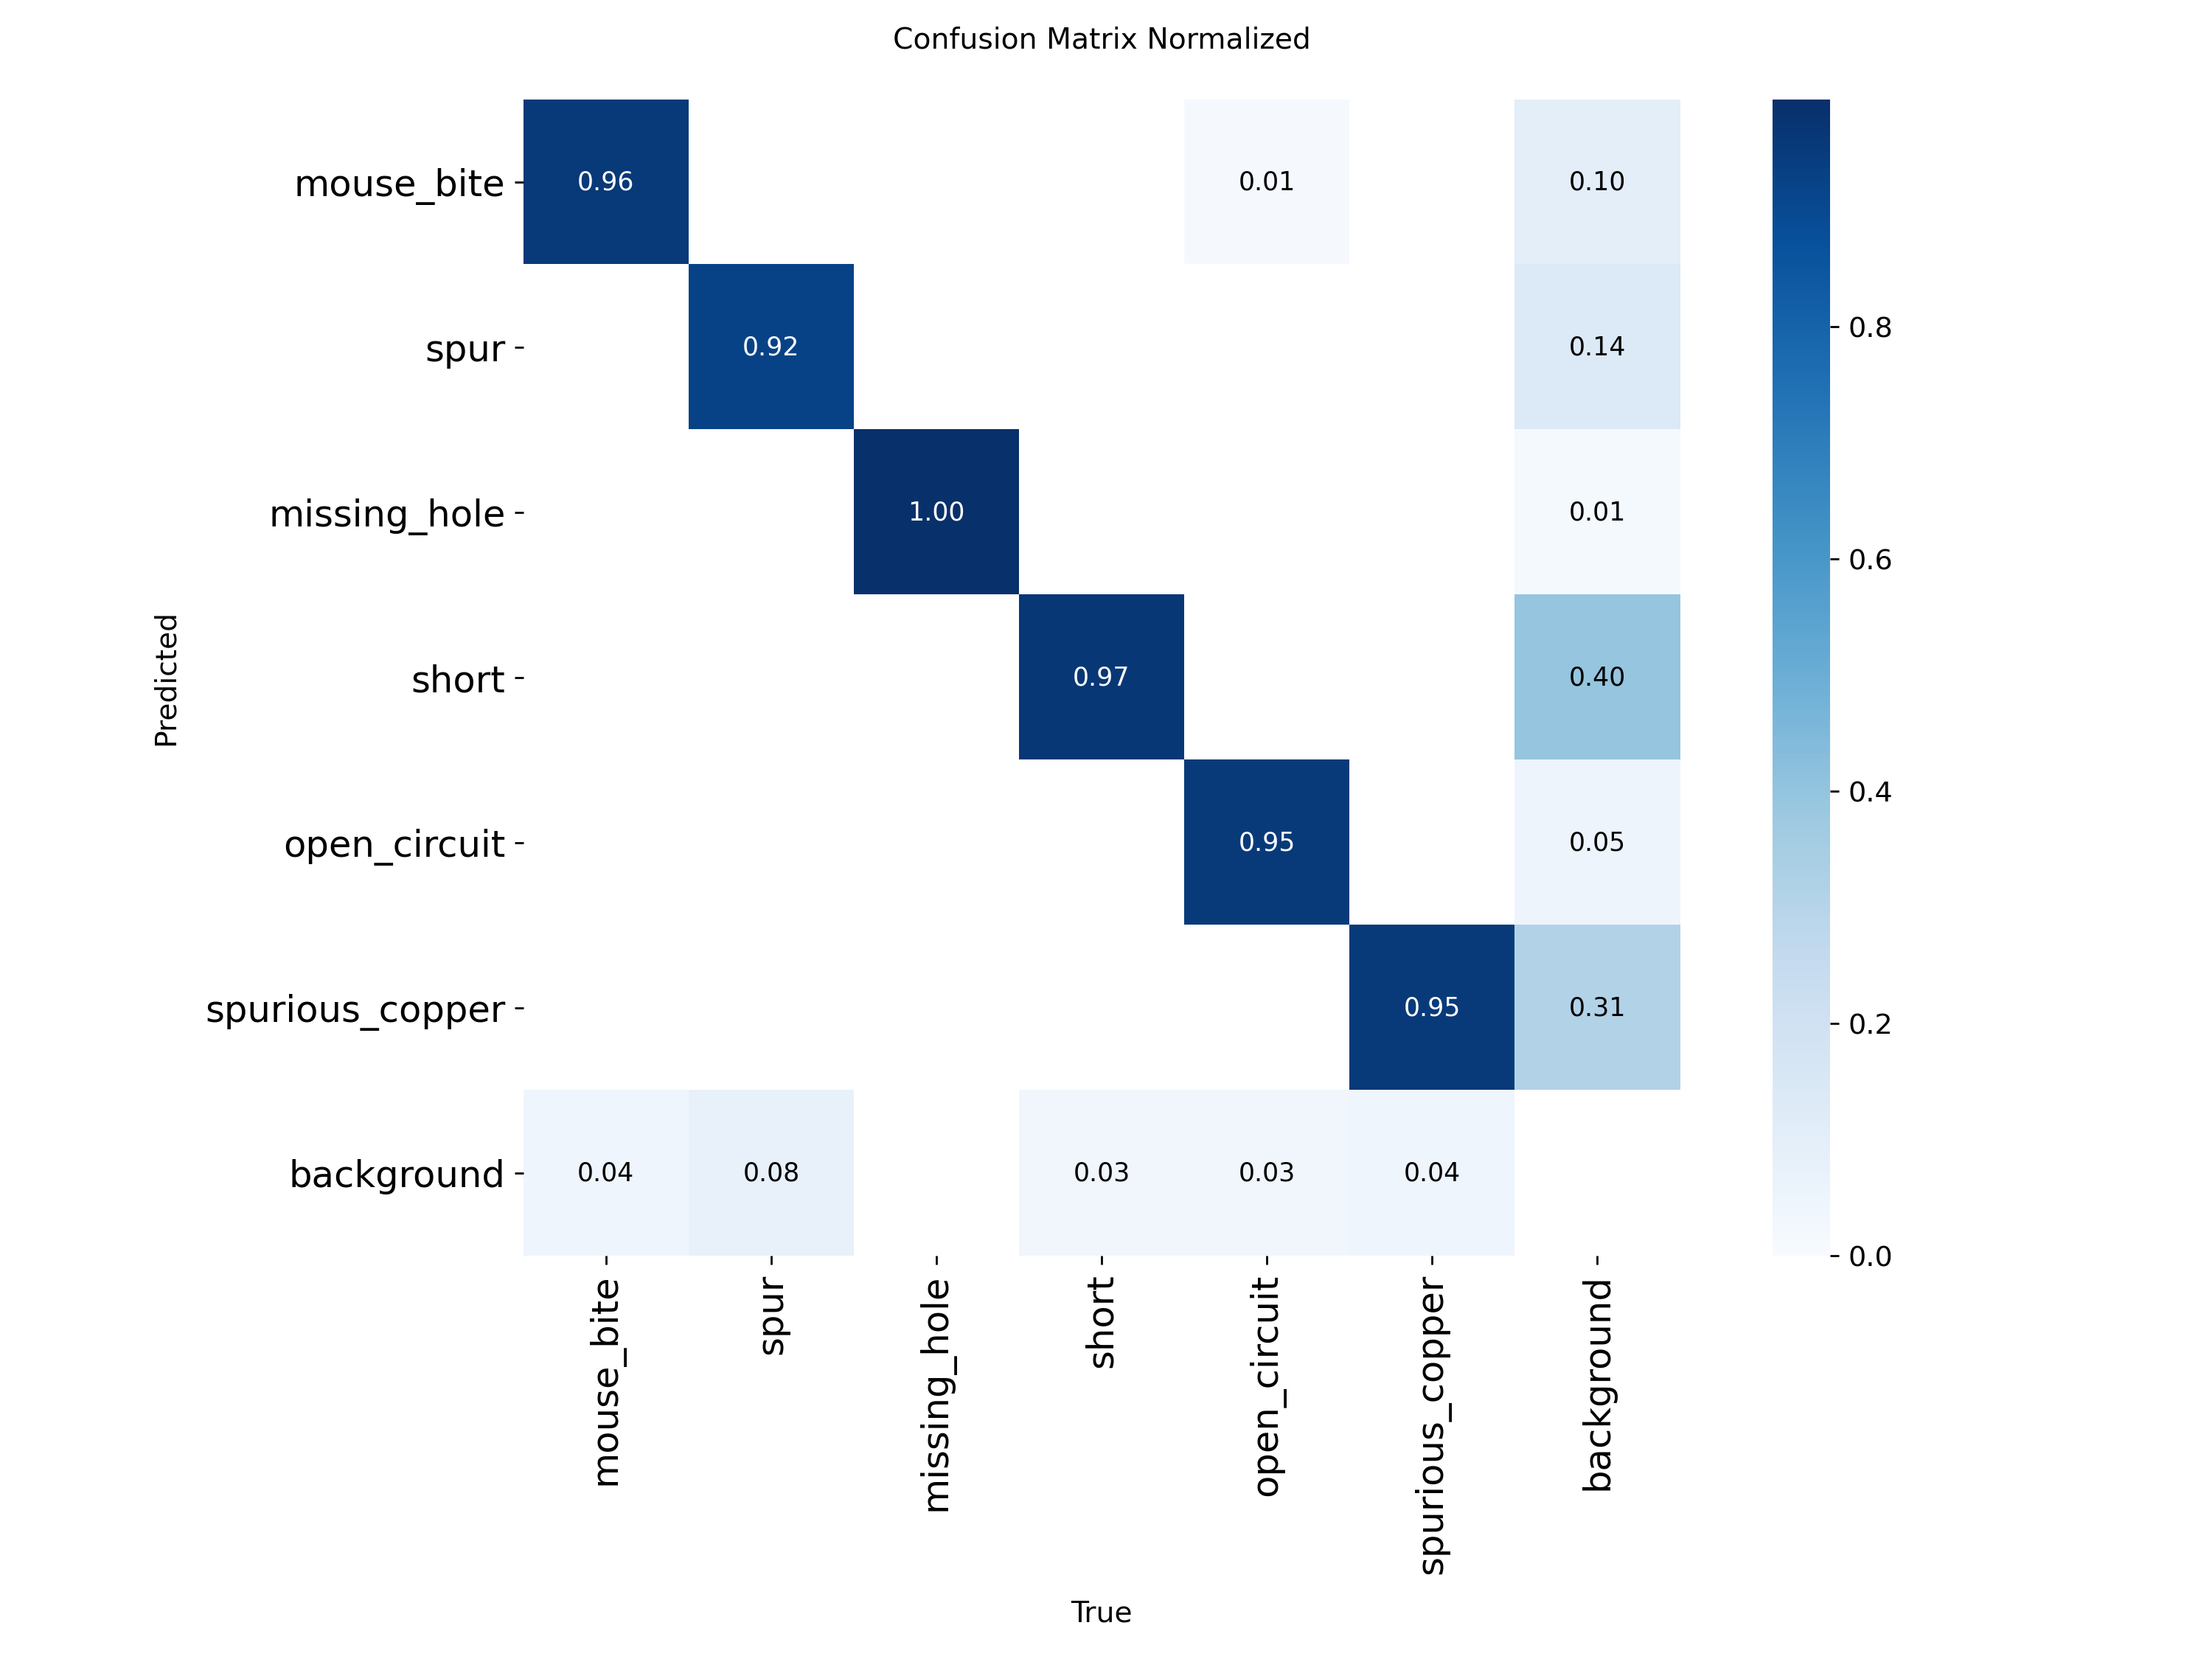

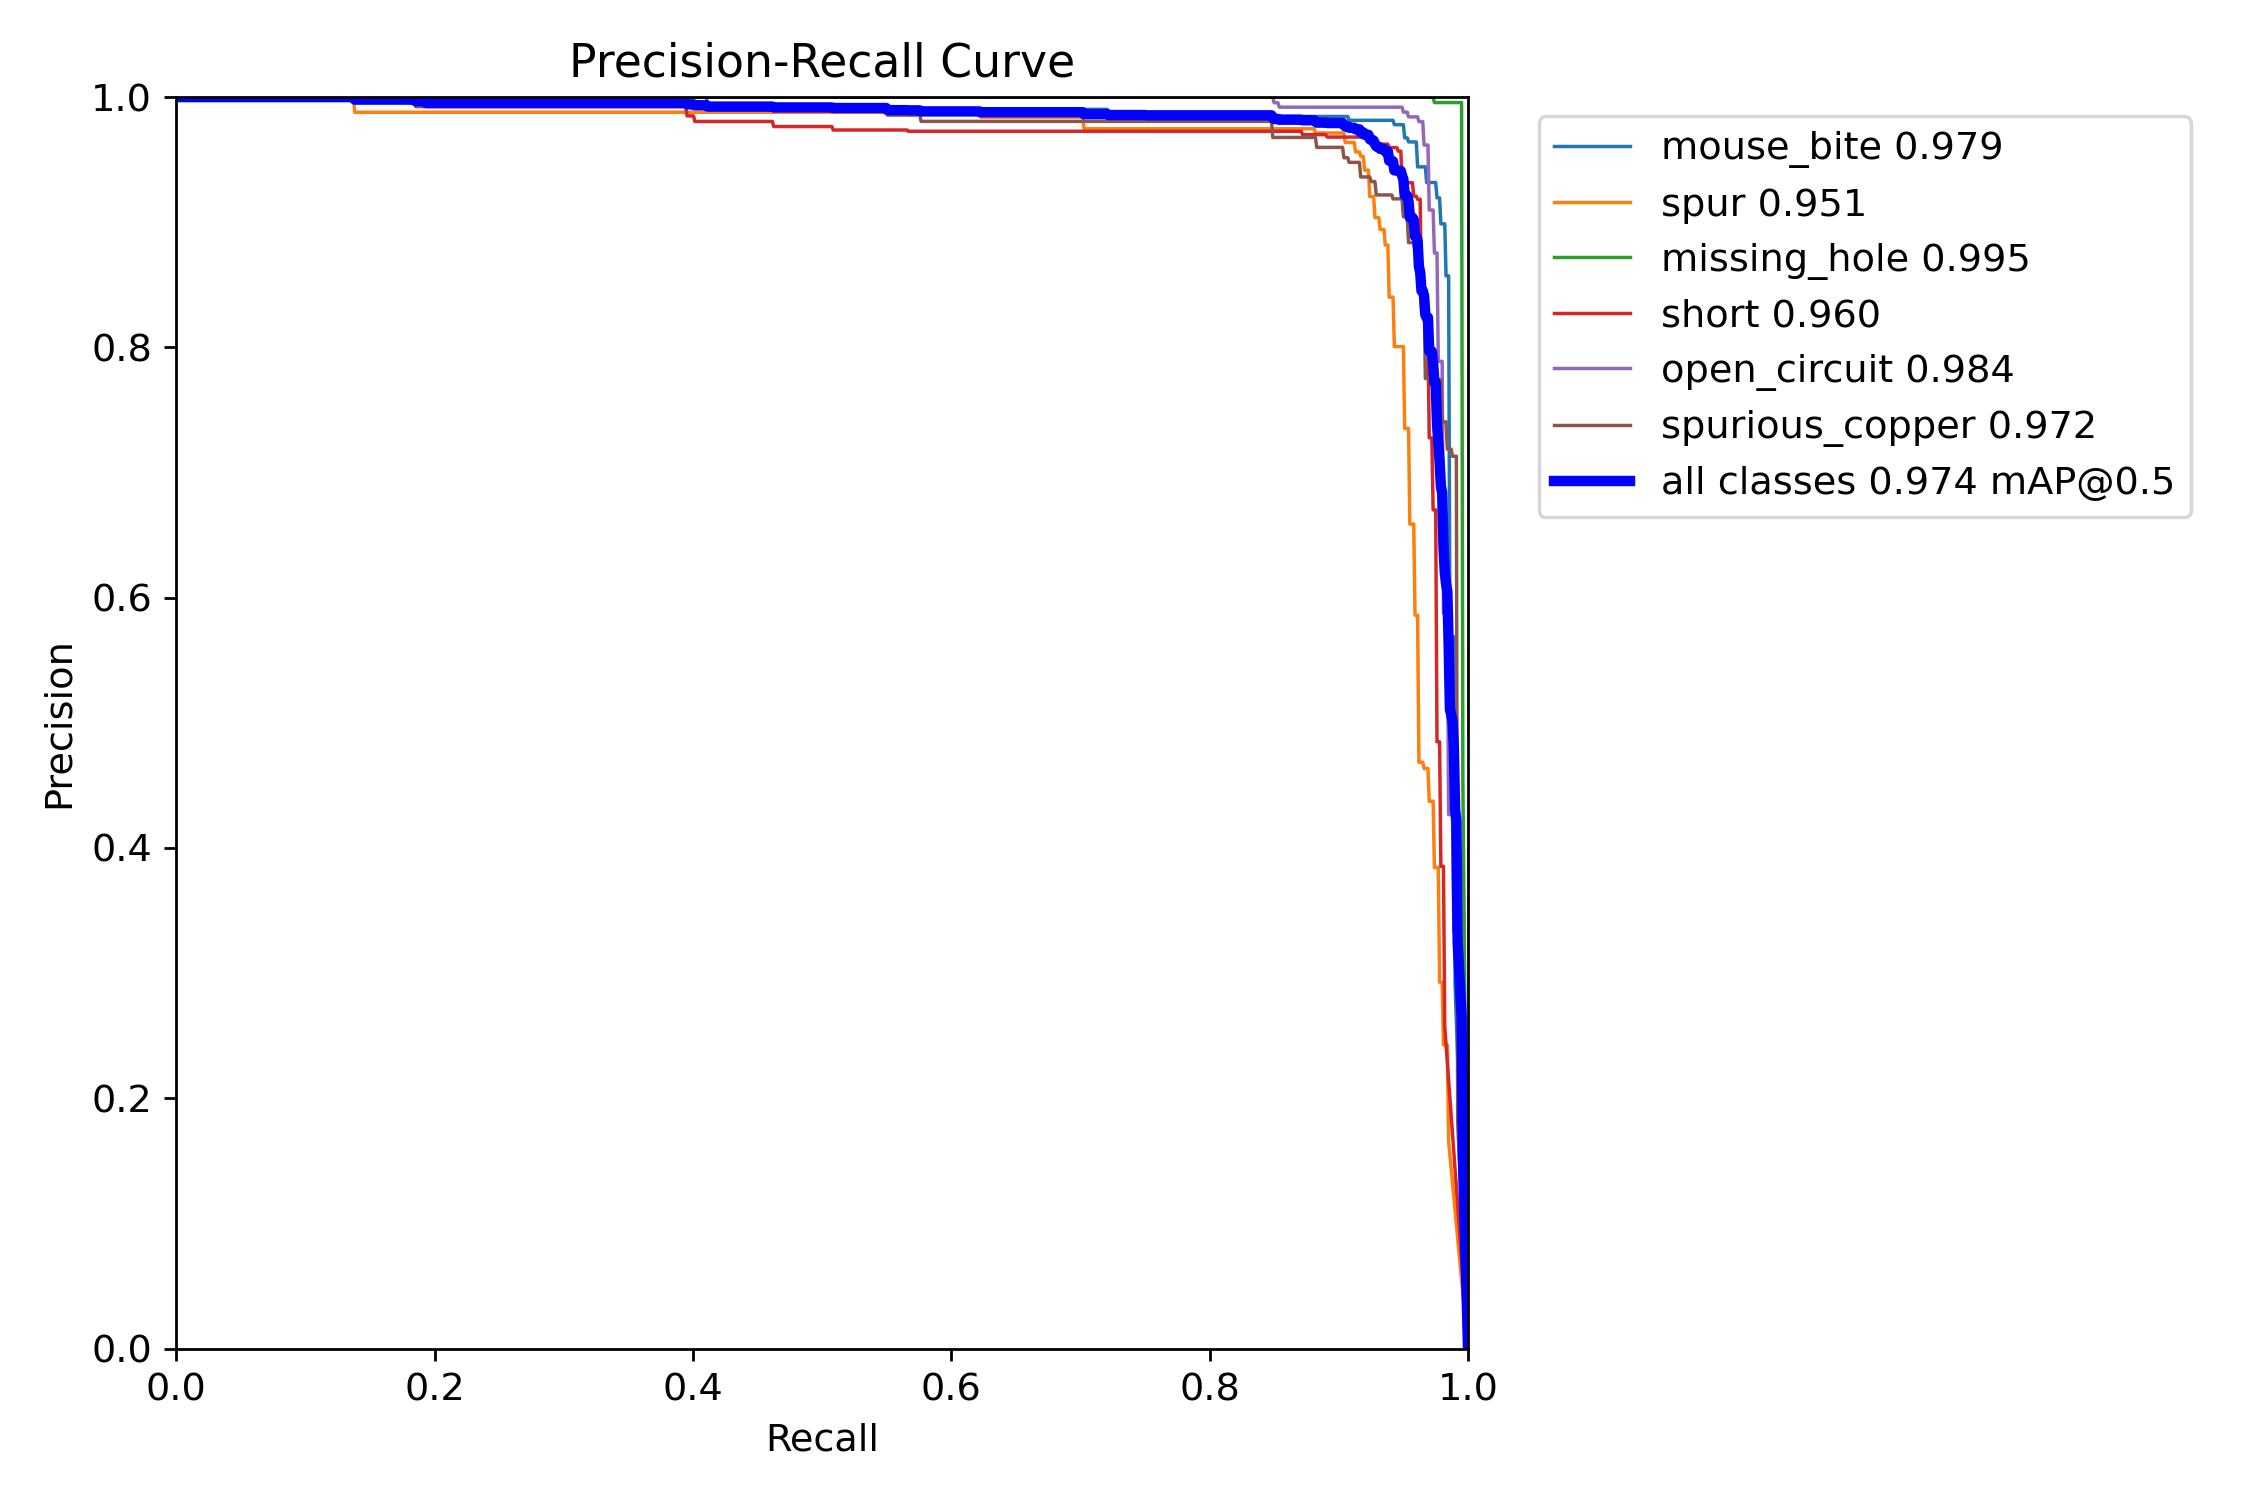

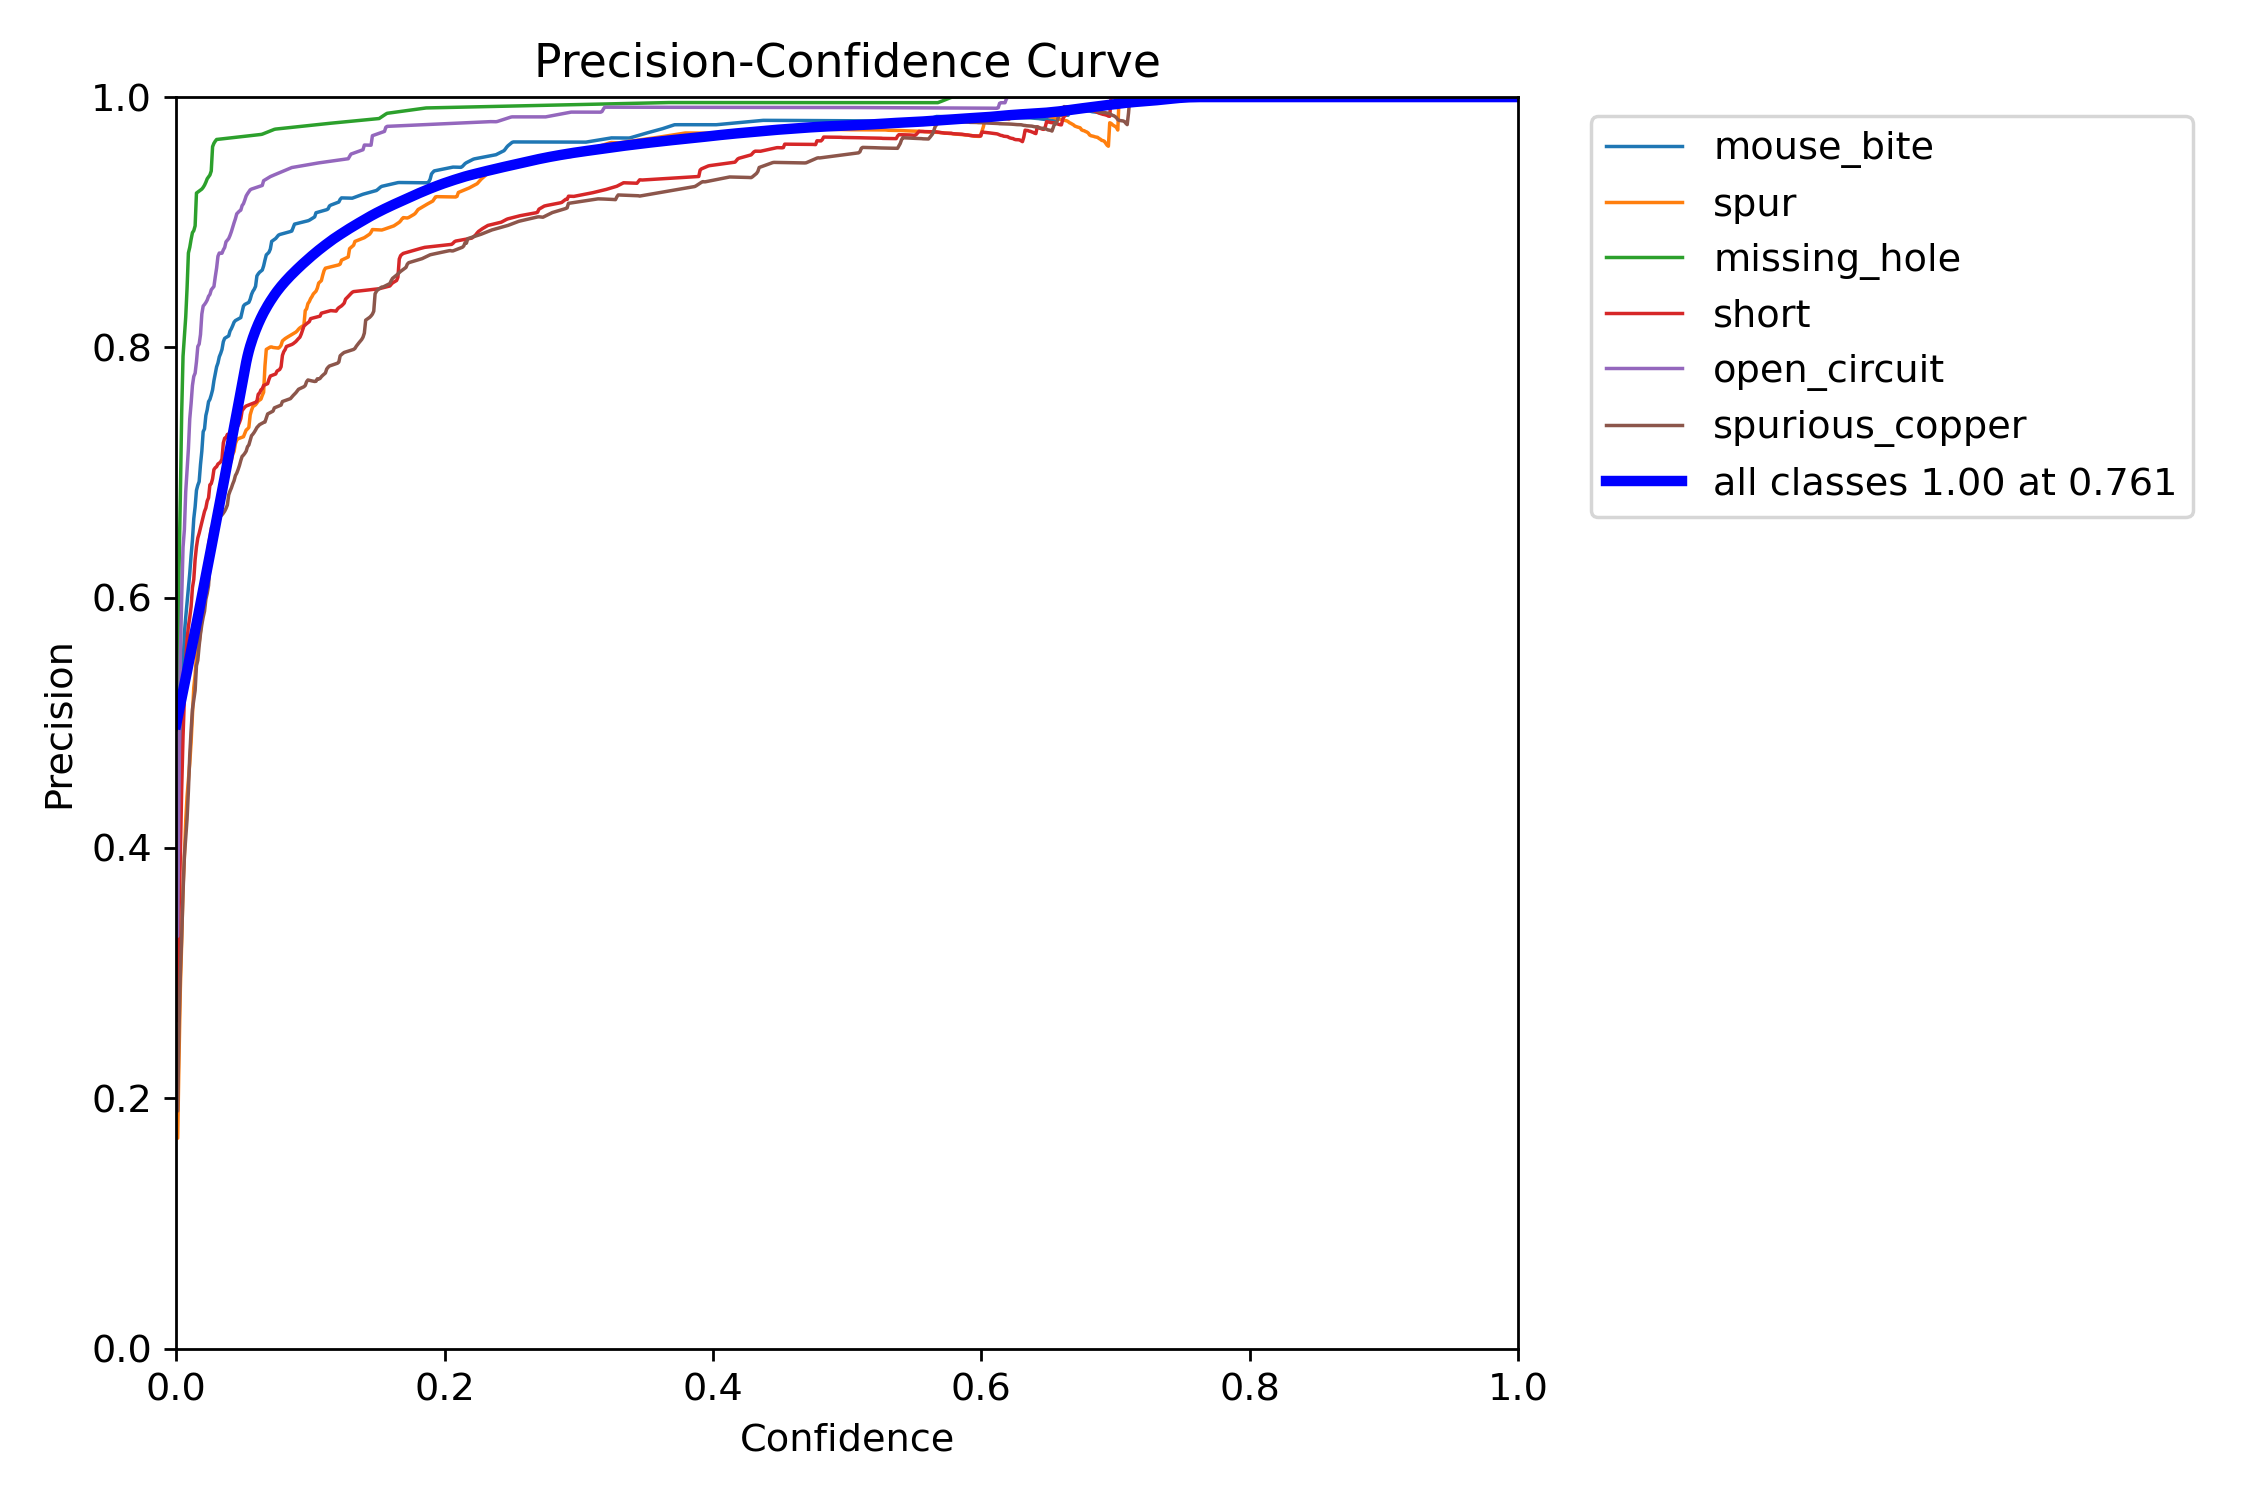

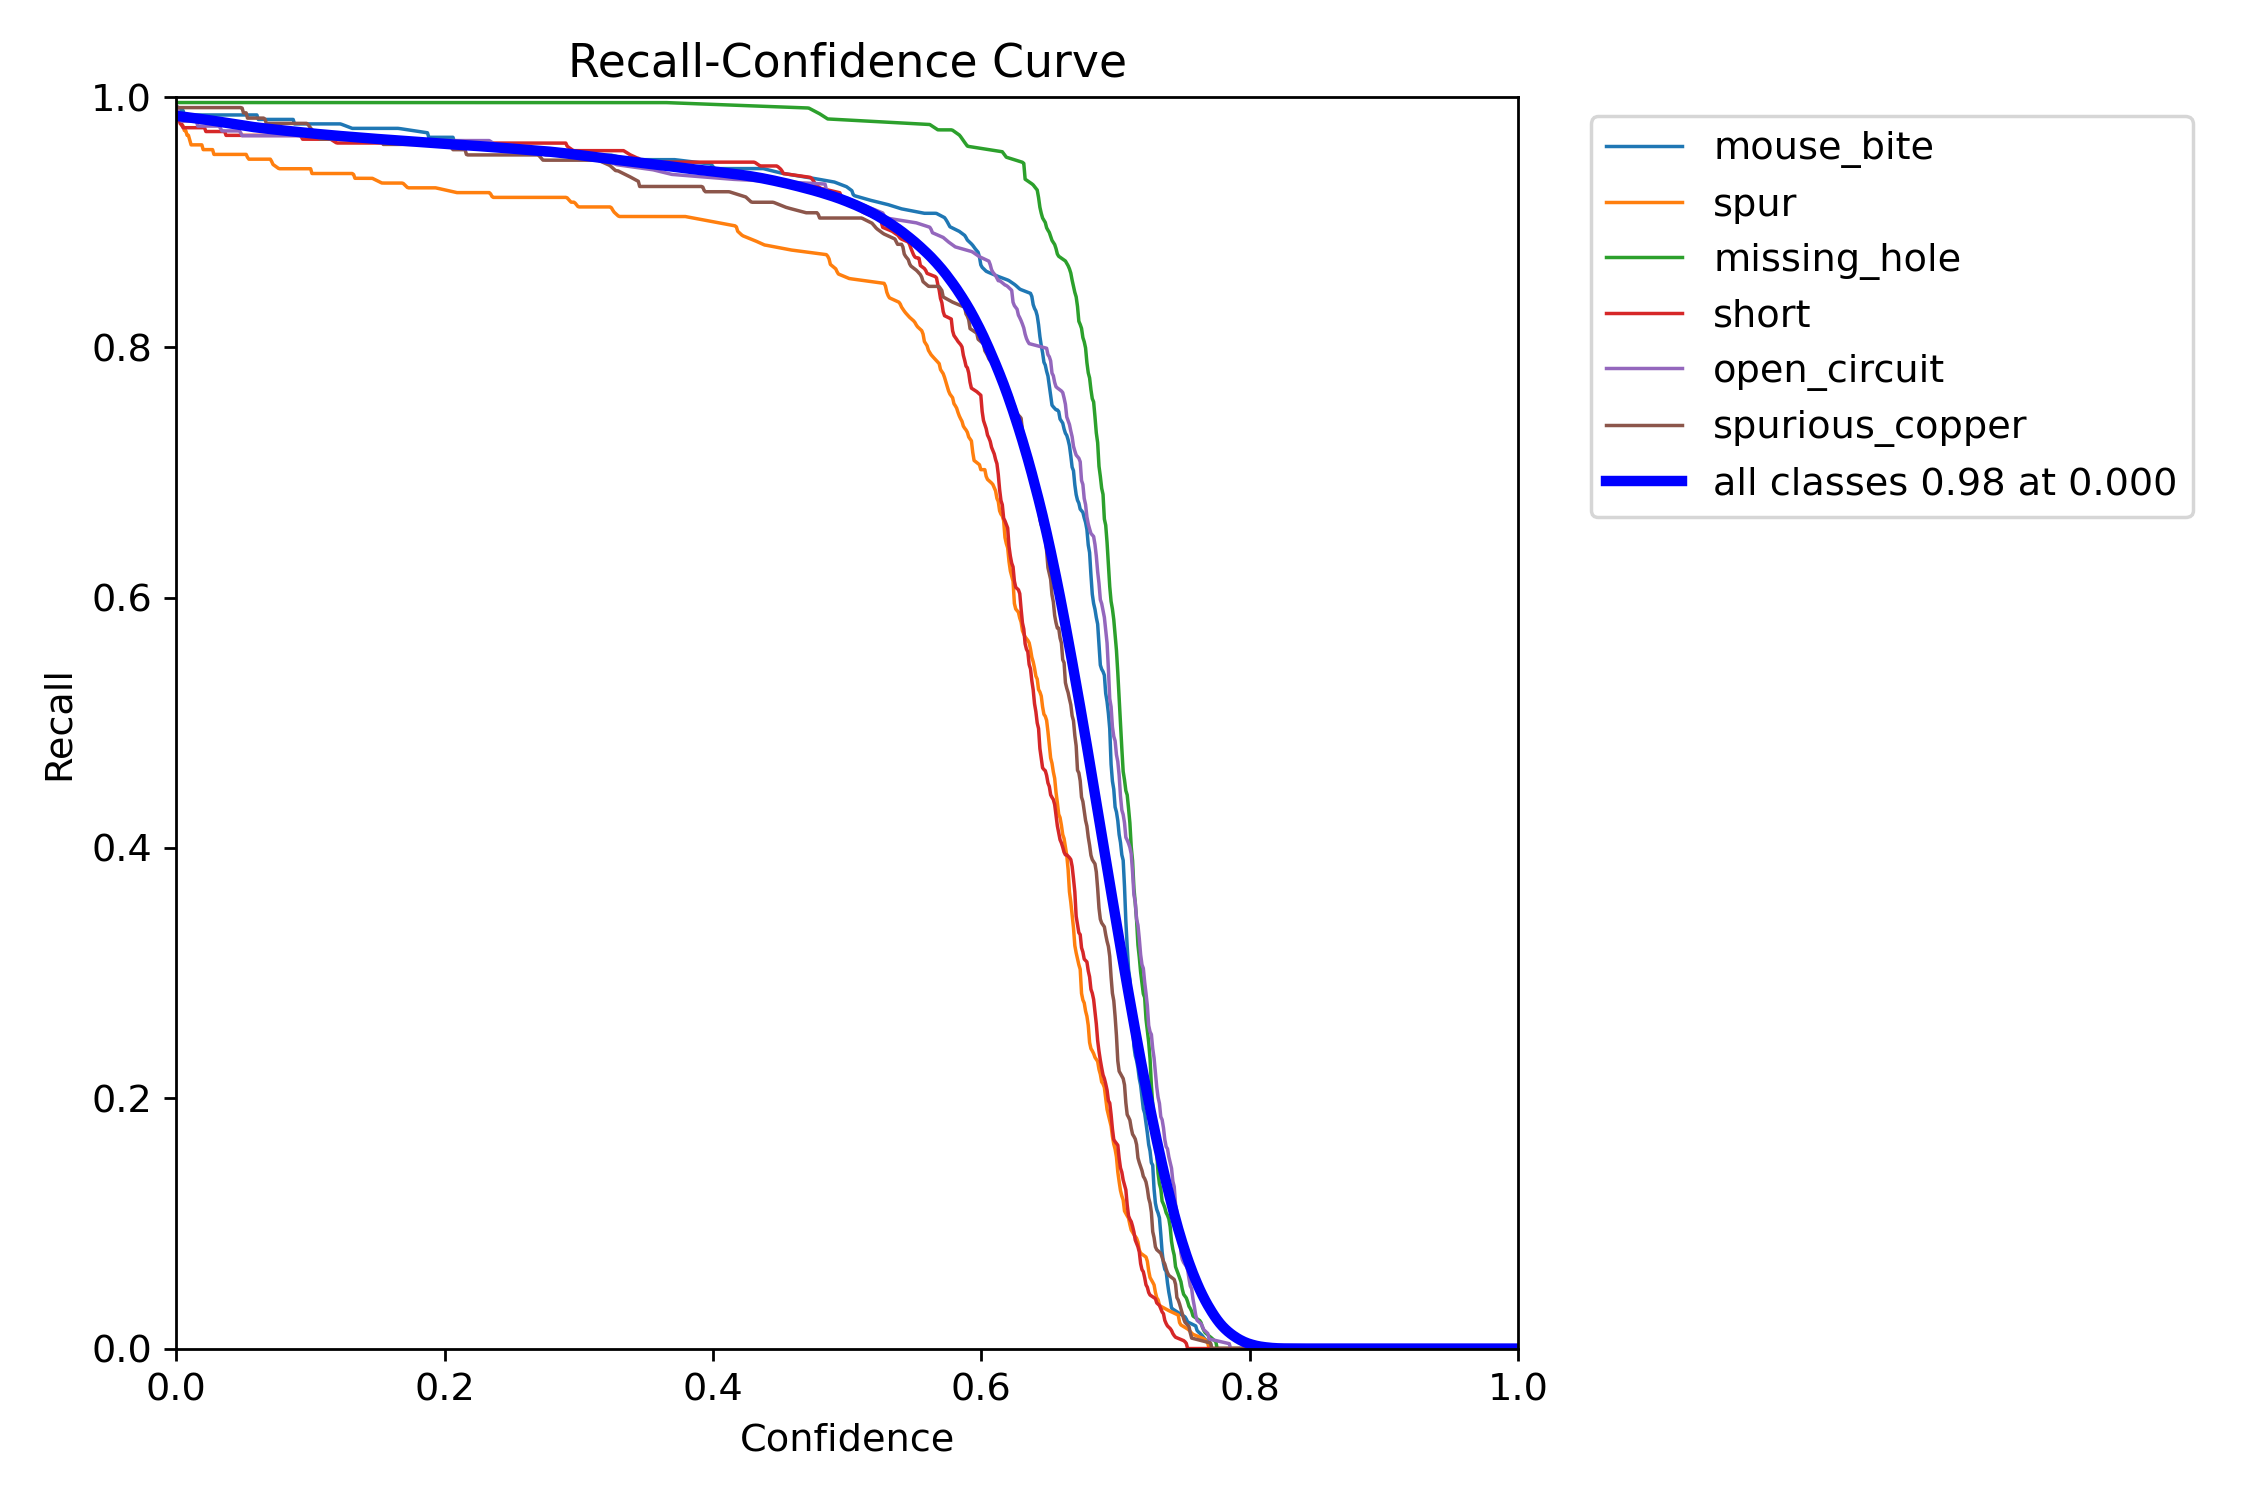

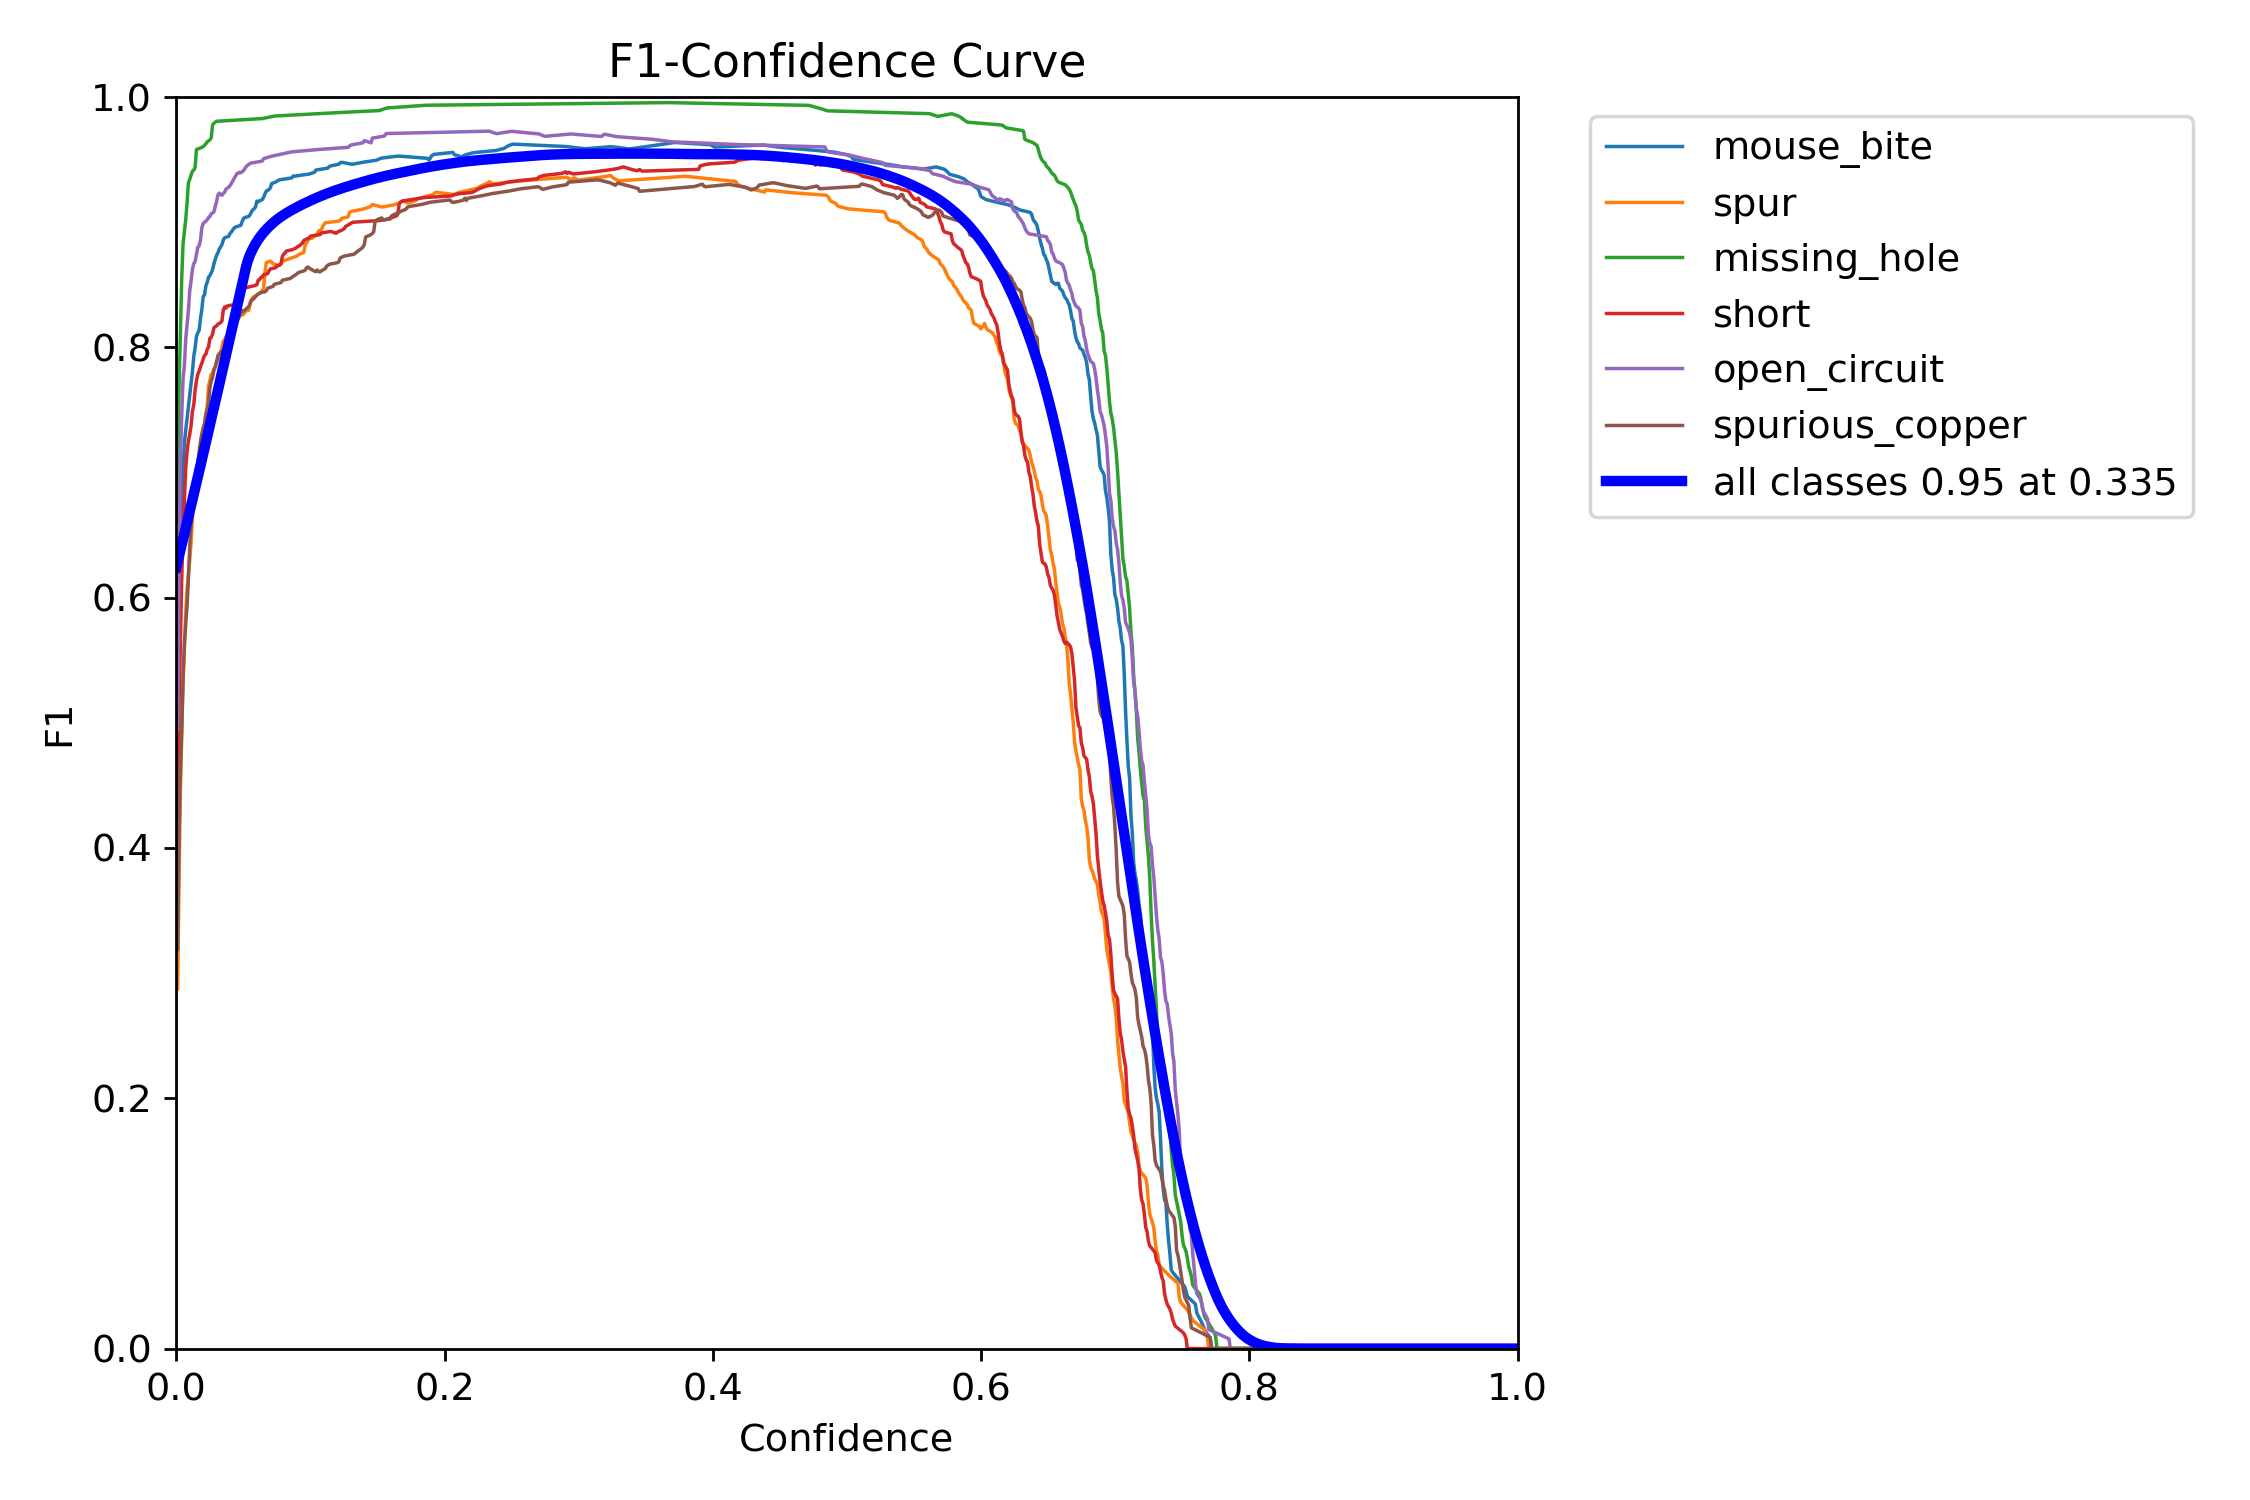

In [27]:
from IPython.display import Image, display
import os

PLOT_DIR = "/kaggle/working/runs/detect/val"

plots = [
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "BoxPR_curve.png",
    "BoxP_curve.png",
    "BoxR_curve.png",
    "BoxF1_curve.png"
]

for p in plots:
    path = os.path.join(PLOT_DIR, p)
    if os.path.exists(path):
        display(Image(filename=path))


In [28]:
import pandas as pd
import numpy as np

precision = metrics_test.box.p.mean()
recall = metrics_test.box.r.mean()
f1 = 2 * precision * recall / (precision + recall)

metrics_df = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1-score", "mAP@0.5", "mAP@0.5:0.95"],
    "Value": [
        precision,
        recall,
        f1,
        metrics_test.box.map50,
        metrics_test.box.map
    ]
})

metrics_df_path = "/kaggle/working/lightweight_test_metrics.csv"
metrics_df.to_csv(metrics_df_path, index=False)
metrics_df


,Metric,Value
0,Precision,0.961211
1,Recall,0.952070
2,F1-score,0.956618
3,mAP@0.5,0.976137
4,mAP@0.5:0.95,0.526235


In [29]:
import shutil
import os

FINAL_DIR = "/kaggle/working/FINAL_LIGHTWEIGHT_PROJECT"
os.makedirs(FINAL_DIR, exist_ok=True)

# Copy model
shutil.copy(MODEL_PATH, FINAL_DIR)

# Copy plots
shutil.copytree(PLOT_DIR, f"{FINAL_DIR}/plots", dirs_exist_ok=True)

# Copy metrics CSV
shutil.copy(metrics_df_path, FINAL_DIR)

# Copy entire training folder (optional but recommended)
TRAIN_DIR = "/kaggle/working/pcb_lightweight"
if os.path.exists(TRAIN_DIR):
    shutil.copytree(TRAIN_DIR, f"{FINAL_DIR}/training_runs", dirs_exist_ok=True)

print("✅ All files collected")


✅ All files collected


In [30]:
ZIP_PATH = "/kaggle/working/LIGHTWEIGHT_YOLO11_FINAL.zip"

if os.path.exists(ZIP_PATH):
    os.remove(ZIP_PATH)

shutil.make_archive(
    base_name=ZIP_PATH.replace(".zip", ""),
    format="zip",
    root_dir=FINAL_DIR
)

print("✅ ZIP created successfully")
print("📦 File:", ZIP_PATH)


✅ ZIP created successfully
📦 File: /kaggle/working/LIGHTWEIGHT_YOLO11_FINAL.zip


In [31]:
!unzip -l /kaggle/working/LIGHTWEIGHT_YOLO11_FINAL.zip | head -n 40


Archive:  /kaggle/working/LIGHTWEIGHT_YOLO11_FINAL.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
        0  2026-01-19 10:07   plots/
        0  2026-01-19 09:07   training_runs/
  5471194  2026-01-19 10:17   lightweight_best.pt
      155  2026-01-19 10:17   lightweight_test_metrics.csv
   206241  2026-01-19 10:07   plots/BoxR_curve.png
   165494  2026-01-19 10:07   plots/BoxP_curve.png
   712416  2026-01-19 10:07   plots/val_batch2_labels.jpg
   650034  2026-01-19 10:07   plots/val_batch1_pred.jpg
   637131  2026-01-19 10:07   plots/val_batch1_labels.jpg
   152953  2026-01-19 10:07   plots/BoxPR_curve.png
   180704  2026-01-19 10:07   plots/confusion_matrix.png
   228937  2026-01-19 10:07   plots/BoxF1_curve.png
   191786  2026-01-19 10:07   plots/confusion_matrix_normalized.png
   748328  2026-01-19 10:07   plots/val_batch0_labels.jpg
   761015  2026-01-19 10:07   plots/val_batch0_pred.jpg
   721137  2026-01-19 10:07   plots/val_batch2_pred.jpg
        0  